# Práctica: Word2Vec mediante Skip-gram

### Objetivo

En esta práctica se implementa un modelo Word2Vec con arquitectura Skip-gram utilizando PyTorch.

El principio de Skip-gram consiste en aprender representaciones vectoriales de palabras a partir de su contexto. Dada una palabra central, el modelo intenta predecir las palabras que aparecen próximas a ella dentro de una ventana determinada.

### 1. Librerías y reproducibilidad

Se utilizan principalmente:

- **PyTorch**, para construir y entrenar el modelo Skip-gram.
- **NumPy**, para operaciones numéricas auxiliares.
- **Pandas**, para organizar los resultados.
- **Matplotlib**, para representar gráficamente las pérdidas y los experimentos.
- **scikit-learn**, únicamente para una visualización bidimensional mediante PCA.

El corpus utilizado es muy pequeño, por lo que no es necesario un tokenizador complejo. Las frases ya presentan un vocabulario controlado y no contienen puntuación problemática, por lo que una tokenización sencilla por espacios es suficiente.

También se fijan semillas aleatorias para mejorar la reproducibilidad de los experimentos. Esto es especialmente importante porque, en un corpus pequeño, distintas inicializaciones de los embeddings pueden producir resultados notablemente diferentes.

In [1]:
from pathlib import Path
from collections import Counter
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from sklearn.decomposition import PCA
from IPython.display import display

In [2]:
SEED = 42


def fijar_semilla(seed=SEED):
    """Fija las semillas utilizadas por Python, NumPy y PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


fijar_semilla()


DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)

PyTorch: 2.8.0
Dispositivo: cpu


### 2. Carga y tokenización del corpus

El corpus se encuentra en el fichero `dataset_word2vec.txt` y contiene frases cortas en español.

Antes de entrenar Word2Vec es necesario convertir cada frase en una secuencia de palabras o **tokens**.

En este caso se realiza un preprocesamiento deliberadamente sencillo:

1. eliminar posibles espacios al principio o final de cada línea;
2. convertir el texto a minúsculas;
3. dividir cada frase utilizando los espacios.

No se eliminan artículos, preposiciones ni otras stopwords. Aunque palabras como `el`, `la` o `en` son muy frecuentes, también forman parte del contexto que Skip-gram debe aprender.

Tampoco se aplica stemming o lematización, ya que diferencias como `perro` / `perra`, `médico` / `médica` o `rey` / `reina` son precisamente relaciones que interesa conservar y analizar posteriormente.

In [3]:
DATA_PATH = Path("dataset_word2vec.txt")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra {DATA_PATH}. "
        "Coloca dataset_word2vec.txt en la misma carpeta que el notebook."
    )


with open(DATA_PATH, encoding="utf-8") as f:
    lineas = [linea.strip() for linea in f if linea.strip()]


def tokenizar(frase):
    """
    Tokenización simple adecuada para este corpus:
    minúsculas + separación por espacios.
    """
    return frase.lower().split()


corpus = [tokenizar(linea) for linea in lineas]


print("Primeras cinco frases tokenizadas:\n")

for frase in corpus[:5]:
    print(frase)

Primeras cinco frases tokenizadas:

['el', 'perro', 'corre', 'en', 'el', 'parque']
['el', 'perro', 'come', 'carne']
['el', 'perro', 'bebe', 'agua']
['el', 'perro', 'duerme', 'en', 'la', 'casa']
['el', 'perro', 'juega', 'con', 'la', 'pelota']


### 3. Análisis exploratorio del corpus

Antes de diseñar el modelo es importante conocer la cantidad de información disponible.

La dimensión del embedding determina cuántos valores debe aprender el modelo para representar cada palabra. Por tanto, su elección debe relacionarse con el tamaño y la riqueza del corpus.

Se analizarán:

- número de frases;
- número total de tokens;
- número de palabras diferentes;
- longitud de las frases;
- frecuencia de las palabras;
- número de palabras que aparecen una única vez.

Este último dato es particularmente relevante. Una palabra que aparece una sola vez proporciona muy poca información contextual, independientemente de que intentemos representarla mediante 4, 32 o 256 dimensiones.

,Valor
Número de frases,251.000000
Número total de tokens,1148.000000
Palabras diferentes,356.000000
Palabras que aparecen una sola vez,172.000000
Longitud media de las frases,4.573705
Longitud mínima,3.000000
Longitud máxima,7.000000


,Palabra,Frecuencia
0,la,131
1,el,129
2,es,37
3,está,27
4,en,26
5,un,20
6,por,15
7,una,15
8,al,14
9,gato,11


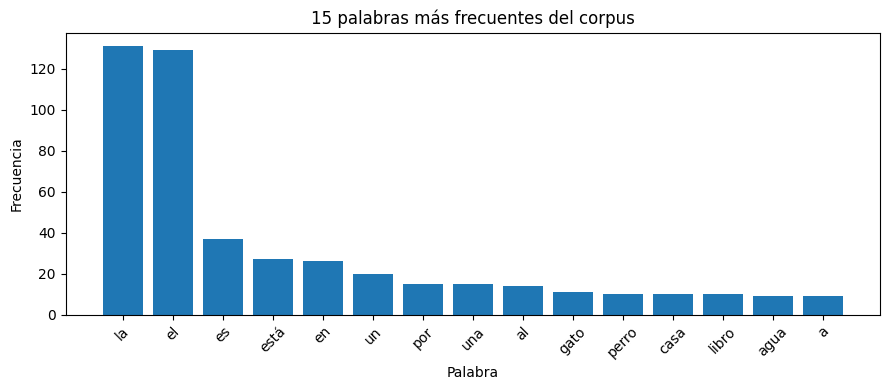

In [4]:
todos_los_tokens = [
    palabra
    for frase in corpus
    for palabra in frase
]

frecuencias = Counter(todos_los_tokens)
longitudes = [len(frase) for frase in corpus]

n_frases = len(corpus)
n_tokens = len(todos_los_tokens)
n_vocabulario = len(frecuencias)
n_hapax = sum(freq == 1 for freq in frecuencias.values())

porcentaje_hapax = 100 * n_hapax / n_vocabulario

estadisticas = pd.DataFrame({
    "Valor": [
        n_frases,
        n_tokens,
        n_vocabulario,
        n_hapax,
        np.mean(longitudes),
        min(longitudes),
        max(longitudes),
    ]
}, index=[
    "Número de frases",
    "Número total de tokens",
    "Palabras diferentes",
    "Palabras que aparecen una sola vez",
    "Longitud media de las frases",
    "Longitud mínima",
    "Longitud máxima",
])

display(estadisticas)


frecuencias_df = pd.DataFrame(
    frecuencias.most_common(15),
    columns=["Palabra", "Frecuencia"]
)

display(frecuencias_df)


plt.figure(figsize=(9, 4))
plt.bar(
    frecuencias_df["Palabra"],
    frecuencias_df["Frecuencia"]
)

plt.xticks(rotation=45)
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.title("15 palabras más frecuentes del corpus")
plt.tight_layout()
plt.show()

### Interpretación del corpus

El corpus contiene 251 frases, 1.148 tokens y 356 palabras diferentes. De estas últimas, 172 aparecen una única vez, lo que representa aproximadamente el 48 % del vocabulario.

Por tanto, existe relativamente poca evidencia contextual para estimar la representación de una parte importante de las palabras. Esta característica debe tenerse en cuenta al seleccionar la dimensión de los embeddings.

Una representación de dimensión muy reducida puede no disponer de capacidad suficiente para separar las distintas relaciones presentes en el corpus. Sin embargo, aumentar la dimensionalidad incrementa también el número de parámetros que deben estimarse utilizando exactamente los mismos datos.

Por ello, la calidad de los embeddings deberá evaluarse mediante su comportamiento en tareas de similitud y analogías, y no únicamente atendiendo a la capacidad del modelo o a la pérdida de entrenamiento.

### 4. Construcción del vocabulario

Una red neuronal no trabaja directamente con palabras. Por ello, cada término del corpus se asocia a un identificador entero.

Se construyen dos diccionarios:

- `palabra2id`: convierte una palabra en su identificador;
- `id2palabra`: realiza la operación inversa.

Si el vocabulario contiene \(V\) palabras, los identificadores estarán comprendidos entre `0` y `V - 1`.

Estos identificadores serán posteriormente las entradas de `nn.Embedding`.

In [5]:
vocabulario = sorted(frecuencias.keys())

palabra2id = {
    palabra: indice
    for indice, palabra in enumerate(vocabulario)
}

id2palabra = {
    indice: palabra
    for palabra, indice in palabra2id.items()
}

V = len(vocabulario)


print("Tamaño del vocabulario:", V)
print("\nPrimeras asociaciones palabra → id:")

for palabra in vocabulario[:10]:
    print(f"{palabra:15s} -> {palabra2id[palabra]}")

Tamaño del vocabulario: 356

Primeras asociaciones palabra → id:
a               -> 0
abierta         -> 1
abierto         -> 2
abre            -> 3
abro            -> 4
abuela          -> 5
abuelo          -> 6
agitado         -> 7
agua            -> 8
al              -> 9


### 5. Generación de pares Skip-gram

Skip-gram aprende intentando predecir el contexto de una palabra central.

Para construir los ejemplos de entrenamiento se utiliza una ventana deslizante.

Con una ventana de tamaño 2, para cada palabra se consideran como contexto hasta dos palabras situadas a su izquierda y dos a su derecha.

Cada pareja `(centro, contexto)` constituye un ejemplo de entrenamiento independiente. En los experimentos principales se utilizará `window = 2`, ya que las frases del corpus son muy cortas. 

In [6]:
def generar_pares(corpus, palabra2id, window=2):
    """
    Genera los pares (palabra_central, palabra_contexto)
    utilizados para entrenar Skip-gram.

    Los valores devueltos son identificadores enteros.
    """
    
    pares = []

    for frase in corpus:
        ids = [palabra2id[palabra] for palabra in frase]

        for i, centro in enumerate(ids):

            inicio = max(0, i - window)
            fin = min(len(ids), i + window + 1)

            for j in range(inicio, fin):

                if i != j:
                    pares.append((centro, ids[j]))

    return torch.tensor(pares, dtype=torch.long)


WINDOW_BASE = 2

pares_base = generar_pares(
    corpus,
    palabra2id,
    window=WINDOW_BASE
)


print("Ventana:", WINDOW_BASE)
print("Número de pares Skip-gram:", len(pares_base))


def mostrar_pares_frase(frase, window=2):
    """Devuelve los pares centro-contexto de una frase en formato legible."""
    
    pares = []

    for i, centro in enumerate(frase):

        inicio = max(0, i - window)
        fin = min(len(frase), i + window + 1)

        for j in range(inicio, fin):

            if i != j:
                pares.append((centro, frase[j]))

    return pd.DataFrame(
        pares,
        columns=["Palabra central", "Palabra de contexto"]
    )


print("\nFrase utilizada como ejemplo:")
print(" ".join(corpus[0]))

display(
    mostrar_pares_frase(
        corpus[0],
        window=WINDOW_BASE
    )
)

Ventana: 2
Número de pares Skip-gram: 3086

Frase utilizada como ejemplo:
el perro corre en el parque


,Palabra central,Palabra de contexto
0,el,perro
1,el,corre
2,perro,el
3,perro,corre
4,perro,en
5,corre,el
6,corre,perro
7,corre,en
8,corre,el
9,en,perro


### Resultado de la generación de pares

Con una ventana de tamaño 2 se generan aproximadamente tres mil pares de entrenamiento a partir de las 251 frases originales.

El número de pares es superior al número de tokens porque una misma palabra participa en varias relaciones centro-contexto.

Es importante distinguir ambos conceptos:

- el **corpus original** proporciona las observaciones lingüísticas;
- los **pares Skip-gram** son los ejemplos que se derivan de esas observaciones para entrenar la red.

Aumentar la ventana produciría más pares, pero también modificaría qué se considera contexto. Por ello, durante el experimento principal sobre `embedding_dim` mantendremos este parámetro constante.


### 6. Modelo Skip-gram en PyTorch

El modelo consta de dos capas principales:

`ID de palabra → Embedding → Capa lineal → Palabras del vocabulario`

La capa `nn.Embedding(V, D)` contiene una matriz con una fila para cada palabra del vocabulario:

- `V` es el tamaño del vocabulario;
- `D` es la dimensión elegida para los embeddings.

Cuando el modelo recibe el identificador de una palabra, `nn.Embedding` devuelve el vector de `D` componentes asociado a ella.

A continuación, una capa `nn.Linear(D, V)` transforma ese vector en una puntuación para cada palabra del vocabulario. Durante el entrenamiento, estas puntuaciones se utilizan para predecir qué término apareció realmente en el contexto de la palabra central.

Los vectores almacenados en `nn.Embedding` son precisamente las representaciones que posteriormente se utilizarán para estudiar vecinos semánticos y resolver analogías.

La dimensión `D` controla la capacidad de estas representaciones: dimensiones mayores proporcionan más grados de libertad, pero incrementan también el número de parámetros que deben aprenderse.

In [7]:
class SkipGram(nn.Module):
    """
    Implementación sencilla de Skip-gram con softmax completo.
    """

    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.output = nn.Linear(
            embedding_dim,
            vocab_size,
            bias=False
        )

        nn.init.normal_(
            self.embedding.weight,
            mean=0.0,
            std=0.1
        )

        nn.init.normal_(
            self.output.weight,
            mean=0.0,
            std=0.1
        )

    def forward(self, centros):
        """
        centros:
            tensor con identificadores de las palabras centrales.
        """

        embeddings = self.embedding(centros)
        logits = self.output(embeddings)

        return logits


def contar_parametros(modelo):
    """Número total de parámetros entrenables."""
    
    return sum(
        parametro.numel()
        for parametro in modelo.parameters()
        if parametro.requires_grad
    )

### Relación entre dimensión y número de parámetros

El modelo contiene dos matrices cuyo tamaño depende directamente de la dimensión del embedding:

- la matriz de embeddings de entrada;
- la matriz de la capa de salida.

Como la capa de salida no utiliza sesgo, el número total de parámetros es igual a `2 × V × D`.

Por tanto, duplicar la dimensión del embedding implica duplicar también el número de parámetros entrenables.

In [8]:
DIMENSIONES = [4, 8, 16, 32, 64, 128, 256]

filas = []

for dim in DIMENSIONES:

    modelo_temporal = SkipGram(
        vocab_size=V,
        embedding_dim=dim
    )

    filas.append({
        "embedding_dim": dim,
        "parámetros": contar_parametros(modelo_temporal)
    })


tabla_parametros = pd.DataFrame(filas)

display(tabla_parametros)

,embedding_dim,parámetros
0,4,2848
1,8,5696
2,16,11392
3,32,22784
4,64,45568
5,128,91136
6,256,182272


La diferencia de complejidad es considerable: el modelo pasa de 2.848 parámetros con D = 4 a 182.272 con D = 256, aunque el corpus continúa conteniendo únicamente 1.148 tokens.

Este crecimiento justifica evaluar si el aumento de capacidad produce realmente mejores representaciones.

### 7. Entrenamiento

El objetivo del entrenamiento es minimizar la entropía cruzada entre:

- la palabra de contexto real;
- las puntuaciones generadas por el modelo para todas las palabras del vocabulario.

Se utilizará el optimizador **Adam**.

Debido al reducido tamaño del corpus, se empleará entrenamiento **full-batch**: todos los pares Skip-gram se procesan en una misma actualización por época.

Esta decisión presenta dos ventajas para esta práctica:

1. el coste computacional sigue siendo muy pequeño;
2. se elimina el tamaño de batch como otro hiperparámetro que podría interferir en el análisis.

In [9]:
def entrenar_skipgram(
    corpus,
    palabra2id,
    vocab_size,
    embedding_dim=32,
    window=2,
    epochs=200,
    lr=0.01,
    seed=42,
    verbose=False
):
    """
    Entrena un modelo Skip-gram y devuelve:
    
    - modelo entrenado
    - historial de pérdida
    """

    fijar_semilla(seed)


    pares = generar_pares(
        corpus,
        palabra2id,
        window=window
    )

    centros = pares[:, 0].to(DEVICE)
    contextos = pares[:, 1].to(DEVICE)

    modelo = SkipGram(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim
    ).to(DEVICE)

    criterio = nn.CrossEntropyLoss()

    optimizador = torch.optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    historial = []


    for epoch in range(epochs):

        modelo.train()
        optimizador.zero_grad()
        logits = modelo(centros)
        loss = criterio(
            logits,
            contextos
        )

        loss.backward()
        optimizador.step()
        historial.append(loss.item())

        if verbose and (
            epoch == 0
            or (epoch + 1) % 50 == 0
            or epoch == epochs - 1
        ):
            print(
                f"Época {epoch + 1:3d}/{epochs} "
                f"| loss = {loss.item():.4f}"
            )

    return modelo.cpu(), historial

### 8. Modelo de referencia

Antes de comparar hiperparámetros entrenaremos un único modelo de referencia. Se utilizarán inicialmente:

- ventana = 2;
- `embedding_dim = 32`;
- 200 épocas;
- learning rate = 0.01.

La dimensión 32 no se considera todavía la mejor dimensión. Se utiliza únicamente como punto de partida razonable para comprobar el funcionamiento completo del modelo.

Posteriormente será el experimento sistemático el que determine qué comportamiento presenta cada tamaño de embedding.

Época   1/200 | loss = 5.8771
Época  50/200 | loss = 3.2891
Época 100/200 | loss = 2.5997
Época 150/200 | loss = 2.5450
Época 200/200 | loss = 2.5347


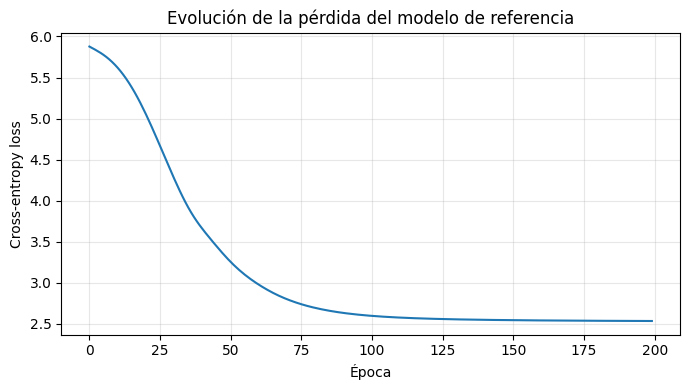

In [10]:
modelo_base, historial_base = entrenar_skipgram(
    corpus=corpus,
    palabra2id=palabra2id,
    vocab_size=V,
    embedding_dim=32,
    window=2,
    epochs=200,
    lr=0.01,
    seed=SEED,
    verbose=True
)


plt.figure(figsize=(7, 4))

plt.plot(historial_base)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")
plt.title("Evolución de la pérdida del modelo de referencia")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la pérdida

El entrenamiento muestra una convergencia clara. La pérdida parte de **5,877** y desciende rápidamente hasta **3,289** en la época 50. Posteriormente continúa reduciéndose de forma más gradual:

- época 100: 2,600;
- época 150: 2,545;
- época 200: 2,535.

La curva indica que la mayor parte del aprendizaje se produce durante las primeras épocas y que posteriormente se alcanza una zona de rendimientos decrecientes.

No se espera que la pérdida llegue a cero, ya que una misma palabra central puede aparecer asociada a múltiples contextos diferentes. Por ejemplo, `perro` aparece junto a verbos como `corre`, `come`, `bebe`, `duerme` o `juega`.

Además, una pérdida menor no garantiza necesariamente embeddings semánticamente mejores. Esta diferencia entre capacidad de ajuste y calidad de las representaciones se comprobará posteriormente al comparar distintas dimensiones.

### 9. Vecinos más cercanos mediante similitud coseno

Una primera forma de evaluar los embeddings consiste en comprobar qué palabras se encuentran próximas en el espacio vectorial.

Se utiliza la **similitud coseno**.

Dos vectores que apuntan en direcciones similares presentan una similitud próxima a 1.

Para cada palabra se calcularán las palabras con mayor similitud coseno, excluyendo la propia palabra consultada.

Esta evaluación es principalmente cualitativa: permite comprobar si el modelo agrupa términos con contextos similares.

In [11]:
def normalizar_embeddings(E):
    """
    Normaliza cada embedding para que tenga norma 1.
    """

    normas = E.norm(
        dim=1,
        keepdim=True
    ).clamp_min(1e-12)

    return E / normas


def vecinos(palabra, E, k=5):
    """
    Obtiene los k vecinos más cercanos mediante similitud coseno.
    """

    if palabra not in palabra2id:
        raise ValueError(
            f"La palabra '{palabra}' no pertenece al vocabulario."
        )

    E_normalizado = normalizar_embeddings(E)
    indice = palabra2id[palabra]
    vector = E_normalizado[indice]
    similitudes = E_normalizado @ vector
    similitudes[indice] = -float("inf")

    indices = torch.topk(
        similitudes,
        k=k
    ).indices.tolist()

    return [
        (
            id2palabra[i],
            float(similitudes[i])
        )
        for i in indices
    ]


def tabla_vecinos(palabras, E, k=5):
    """
    Construye una tabla legible de vecinos.
    """

    filas = []

    for palabra in palabras:

        resultados = vecinos(
            palabra,
            E,
            k=k
        )

        filas.append({
            "palabra": palabra,
            "vecinos": ", ".join(
                f"{vecino} ({sim:.3f})"
                for vecino, sim in resultados
            )
        })

    return pd.DataFrame(filas).set_index("palabra")


embeddings_base = (
    modelo_base
    .embedding
    .weight
    .detach()
    .clone()
)


palabras_consulta = [
    "perro",
    "gata",
    "coche",
    "parís",
    "francia",
    "médico",
    "niña",
    "verano"
]


display(
    tabla_vecinos(
        palabras_consulta,
        embeddings_base,
        k=5
    )
)

,vecinos
palabra,
perro,"gato (0.831), hermano (0.601), patio (0.582), ..."
gata,"perra (0.808), gato (0.628), cuerda (0.591), b..."
coche,"verano (0.665), lento (0.653), profesor (0.643..."
parís,"roma (0.991), madrid (0.989), españa (0.787), ..."
francia,"españa (0.986), italia (0.986), país (0.792), ..."
médico,"enfermero (0.839), hermano (0.590), alumno (0...."
niña,"niño (0.788), madre (0.653), costa (0.637), mé..."
verano,"invierno (0.737), coche (0.665), profesor (0.6..."


### Interpretación de los vecinos

Los resultados muestran que el modelo ha aprendido varias relaciones coherentes con el corpus.

`perro` presenta como vecino principal a `gato` con una similitud de **0,831**, mientras que `gata` tiene como vecino más próximo a `perra` con **0,808**.

Las relaciones geográficas son especialmente claras. Para `parís`, los dos primeros vecinos son `roma` y `madrid`, con similitudes de **0,991** y **0,989**. De forma análoga, los primeros vecinos de `francia` son `españa` e `italia`, ambos con una similitud aproximada de **0,986**.

También aparecen relaciones coherentes en otros grupos, como `médico`–`enfermero`, `niña`–`niño` y `verano`–`invierno`.

No todos los vecinos resultan semánticamente intuitivos. Por ejemplo, `coche` presenta algunos términos poco relacionados entre sus vecinos próximos. Esto es esperable debido al reducido tamaño del corpus y a la baja frecuencia de muchas palabras.

Los resultados muestran, por tanto, que Word2Vec está capturando principalmente **similitud distribucional**: palabras que aparecen en contextos parecidos tienden a ocupar regiones próximas del espacio vectorial.

### 10. Analogías vectoriales

Además de estudiar palabras próximas, los embeddings permiten analizar relaciones mediante operaciones vectoriales.

Para una analogía del tipo:

`a : b :: c : ?`

se construye el vector:

`q = vector(b) - vector(a) + vector(c)`

y se busca la palabra cuyo embedding presenta mayor similitud coseno con `q`.

Por ejemplo:

`francia - parís + madrid ≈ españa`

La operación aritmética se realiza utilizando los embeddings originales. Posteriormente se normaliza el vector resultante para calcular las similitudes mediante coseno.

Las palabras utilizadas en la consulta se excluyen de las posibles respuestas.

In [12]:
def analogia(a, b, c, E, k=3):
    """
    Resuelve analogías del tipo:

        a : b :: c : ?

    calculando:

        vector(b) - vector(a) + vector(c)
    """

    for palabra in (a, b, c):
        if palabra not in palabra2id:
            raise ValueError(
                f"La palabra '{palabra}' no pertenece al vocabulario."
            )

    q = (
        E[palabra2id[b]]
        - E[palabra2id[a]]
        + E[palabra2id[c]]
    )

    q = q / q.norm().clamp_min(1e-12)
    E_normalizado = normalizar_embeddings(E)
    similitudes = E_normalizado @ q

    for palabra in (a, b, c):
        similitudes[palabra2id[palabra]] = -float("inf")

    indices = torch.topk(
        similitudes,
        k=k
    ).indices.tolist()

    return [
        (
            id2palabra[i],
            float(similitudes[i])
        )
        for i in indices
    ]


consultas = [
    ("parís", "francia", "madrid"),
    ("madrid", "españa", "roma"),
    ("roma", "italia", "parís"),
    ("perro", "perra", "gato"),
    ("médico", "médica", "enfermero"),
    ("niño", "niña", "maestro"),
]


filas = []

for a, b, c in consultas:

    resultado = analogia(
        a,
        b,
        c,
        embeddings_base,
        k=3
    )

    filas.append({
        "Analogía": f"{a} : {b} :: {c} : ?",
        "Top-3": ", ".join(
            f"{palabra} ({sim:.3f})"
            for palabra, sim in resultado
        )
    })


display(
    pd.DataFrame(filas)
)

,Analogía,Top-3
0,parís : francia :: madrid : ?,"españa (0.983), italia (0.976), palacio (0.786)"
1,madrid : españa :: roma : ?,"italia (0.985), francia (0.983), palacio (0.819)"
2,roma : italia :: parís : ?,"españa (0.981), francia (0.979), madrid (0.793)"
3,perro : perra :: gato : ?,"gata (0.838), ciudad (0.611), bajo (0.553)"
4,médico : médica :: enfermero : ?,"voy (0.784), hermana (0.769), madre (0.693)"
5,niño : niña :: maestro : ?,"historia (0.816), lección (0.805), guía (0.744)"


### Primeros resultados

Las analogías geográficas funcionan especialmente bien. El modelo obtiene correctamente:

- `parís : francia :: madrid : españa`;
- `madrid : españa :: roma : italia`.

También resuelve la relación de género `perro : perra :: gato : gata`.

Sin embargo, algunas relaciones basadas en profesiones presentan mayores dificultades. Por ejemplo, las consultas relacionadas con `médico` / `médica` y `niño` / `niña` no recuperan la respuesta esperada entre las primeras posiciones.

Estas diferencias justifican utilizar una batería mayor de analogías en lugar de evaluar el modelo únicamente mediante ejemplos seleccionados.

### 11. Evaluación cuantitativa mediante analogías

Para comparar distintas configuraciones no resulta suficiente seleccionar únicamente ejemplos que hayan funcionado bien.

Se define una batería fija de analogías cuya respuesta esperada conocemos a partir de las estructuras presentes en el corpus.

Se utilizarán dos métricas:

#### Top-1

Porcentaje de analogías en las que la respuesta correcta es la palabra con mayor similitud.

#### Top-3

Porcentaje de analogías en las que la respuesta correcta se encuentra entre las tres primeras candidatas.

El Top-1 es una métrica más estricta, mientras que Top-3 resulta útil en este corpus porque algunas palabras aparecen en contextos casi idénticos y pueden resultar difíciles de diferenciar.

Esta batería es pequeña y no constituye un benchmark lingüístico general. Se utiliza únicamente para comparar de forma consistente los modelos entrenados sobre este corpus.

In [13]:
EVAL_ANALOGIAS = [
    ("parís", "francia", "madrid", "españa"),
    ("madrid", "españa", "roma", "italia"),
    ("roma", "italia", "parís", "francia"),

    ("perro", "perra", "gato", "gata"),
    ("gato", "gata", "perro", "perra"),

    ("niño", "niña", "maestro", "maestra"),
    ("médico", "médica", "enfermero", "enfermera"),

    ("panadero", "panadera", "cocinero", "cocinera"),
    ("pintor", "pintora", "jardinero", "jardinera"),
    ("camarero", "camarera", "conductor", "conductora"),
    ("ingeniero", "ingeniera", "programador", "programadora"),

    ("padre", "madre", "hermano", "hermana"),
    ("alumno", "alumna", "profesor", "profesora"),
    ("abuelo", "abuela", "rey", "reina"),
]


assert all(
    palabra in palabra2id
    for analogia_eval in EVAL_ANALOGIAS
    for palabra in analogia_eval
)


def evaluar_analogias(E):
    """
    Evalúa los embeddings mediante la batería fija de analogías.
    """

    aciertos_top1 = 0
    aciertos_top3 = 0
    detalles = []

    for a, b, c, esperado in EVAL_ANALOGIAS:

        candidatos = analogia(
            a,
            b,
            c,
            E,
            k=3
        )

        palabras_candidatas = [
            palabra
            for palabra, _ in candidatos
        ]

        correcto_top1 = (
            palabras_candidatas[0] == esperado
        )

        correcto_top3 = (
            esperado in palabras_candidatas
        )

        aciertos_top1 += correcto_top1
        aciertos_top3 += correcto_top3

        detalles.append({
            "Analogía": f"{a}:{b} :: {c}:?",
            "Esperado": esperado,
            "Top-1": palabras_candidatas[0],
            "Top-3": ", ".join(palabras_candidatas),
            "Correcto Top-1": correcto_top1,
            "Correcto Top-3": correcto_top3,
        })

    n = len(EVAL_ANALOGIAS)
    top1 = aciertos_top1 / n
    top3 = aciertos_top3 / n

    return top1, top3, pd.DataFrame(detalles)


top1_base, top3_base, detalle_base = evaluar_analogias(
    embeddings_base
)

print(f"Top-1 modelo base: {top1_base:.1%}")
print(f"Top-3 modelo base: {top3_base:.1%}")

display(detalle_base)

Top-1 modelo base: 71.4%
Top-3 modelo base: 85.7%


,Analogía,Esperado,Top-1,Top-3,Correcto Top-1,Correcto Top-3
0,parís:francia :: madrid:?,españa,españa,"españa, italia, palacio",True,True
1,madrid:españa :: roma:?,italia,italia,"italia, francia, palacio",True,True
2,roma:italia :: parís:?,francia,españa,"españa, francia, madrid",False,True
3,perro:perra :: gato:?,gata,gata,"gata, ciudad, bajo",True,True
4,gato:gata :: perro:?,perra,perra,"perra, cuerda, costa",True,True
5,niño:niña :: maestro:?,maestra,historia,"historia, lección, guía",False,False
6,médico:médica :: enfermero:?,enfermera,voy,"voy, hermana, madre",False,False
7,panadero:panadera :: cocinero:?,cocinera,cocinera,"cocinera, guitarra, música",True,True
8,pintor:pintora :: jardinero:?,jardinera,jardinera,"jardinera, plantas, empieza",True,True
9,camarero:camarera :: conductor:?,conductora,conductora,"conductora, por, ayuda",True,True


### Resultado del modelo de referencia

El modelo de referencia obtiene un **71,4 % de aciertos Top-1** y un **85,7 % Top-3** sobre las 14 analogías evaluadas.

Las relaciones geográficas y muchas de las transformaciones masculino–femenino se recuperan correctamente. Las principales dificultades aparecen en algunas profesiones o términos cuya evidencia contextual es menor.

La diferencia entre Top-1 y Top-3 también indica que, en algunos casos, el modelo sitúa la respuesta correcta en una región adecuada del espacio aunque no sea la candidata con máxima similitud.

### 12. Experimento principal: dimensión del embedding

Se estudiarán las siguientes dimensiones: {4,8,16,32,64,128,256}

El rango incluye desde representaciones extremadamente comprimidas hasta una dimensionalidad muy alta en relación con el tamaño del corpus.

Para realizar una comparación justa se mantendrán constantes:
- ventana = 2;
- épocas = 200;
- learning rate = 0.01;
- corpus;
- arquitectura;
- función de pérdida;
- optimizador.

Por tanto, el único cambio sistemático será `embedding_dim`.


### Uso de varias semillas

Los pesos iniciales de una red neuronal son aleatorios.

Con un corpus grande, pequeñas diferencias de inicialización suelen tener un impacto limitado. Sin embargo, en este corpus los datos son escasos y una única ejecución podría dar una impresión engañosa.

Por ello, cada dimensión se entrenará utilizando tres semillas diferentes.

Se calcularán:

- pérdida media y desviación típica;
- Top-1 medio y desviación típica;
- Top-3 medio y desviación típica;
- número de parámetros.

Esto permitirá evaluar no solo el rendimiento medio de cada dimensión, sino también su estabilidad.

In [14]:
SEMILLAS_EXPERIMENTO = [0, 1, 2]


def experimento_dimensiones(
    dimensiones,
    semillas,
    window=2,
    epochs=200,
    lr=0.01
):
    """
    Entrena varias dimensiones con diferentes semillas.

    Devuelve:
    - DataFrame con resultados agregados.
    - Modelo de la primera semilla para cada dimensión,
      que utilizaremos después para inspección cualitativa.
    """

    filas = []
    modelos_referencia = {}

    for dim in dimensiones:

        print(f"Embedding dimension = {dim}")

        resultados = []

        for seed in semillas:

            modelo, historial = entrenar_skipgram(
                corpus=corpus,
                palabra2id=palabra2id,
                vocab_size=V,
                embedding_dim=dim,
                window=window,
                epochs=epochs,
                lr=lr,
                seed=seed,
                verbose=False
            )

            E = (
                modelo
                .embedding
                .weight
                .detach()
                .clone()
            )

            top1, top3, _ = evaluar_analogias(E)

            resultados.append([
                historial[-1],
                top1,
                top3
            ])

            # Guardamos un modelo representativo por dimensión
            if seed == semillas[0]:
                modelos_referencia[dim] = modelo

        resultados = np.array(resultados)

        modelo_auxiliar = SkipGram(
            vocab_size=V,
            embedding_dim=dim
        )

        filas.append({
            "embedding_dim": dim,

            "parametros": contar_parametros(
                modelo_auxiliar
            ),

            "loss_mean": resultados[:, 0].mean(),
            "loss_std": resultados[:, 0].std(),

            "top1_mean": resultados[:, 1].mean(),
            "top1_std": resultados[:, 1].std(),

            "top3_mean": resultados[:, 2].mean(),
            "top3_std": resultados[:, 2].std(),
        })

    return (
        pd.DataFrame(filas),
        modelos_referencia
    )


resultados_dim, modelos_dim = experimento_dimensiones(
    dimensiones=DIMENSIONES,
    semillas=SEMILLAS_EXPERIMENTO,
    window=2,
    epochs=200,
    lr=0.01
)


tabla_dim = resultados_dim.copy()

tabla_dim["loss"] = tabla_dim.apply(
    lambda fila:
    f"{fila['loss_mean']:.3f} ± {fila['loss_std']:.3f}",
    axis=1
)

tabla_dim["Top-1"] = tabla_dim.apply(
    lambda fila:
    f"{fila['top1_mean']:.1%} ± {fila['top1_std']:.1%}",
    axis=1
)

tabla_dim["Top-3"] = tabla_dim.apply(
    lambda fila:
    f"{fila['top3_mean']:.1%} ± {fila['top3_std']:.1%}",
    axis=1
)


display(
    tabla_dim[
        [
            "embedding_dim",
            "parametros",
            "loss",
            "Top-1",
            "Top-3"
        ]
    ]
)

Embedding dimension = 4
Embedding dimension = 8
Embedding dimension = 16
Embedding dimension = 32
Embedding dimension = 64
Embedding dimension = 128
Embedding dimension = 256


,embedding_dim,parametros,loss,Top-1,Top-3
0,4,2848,3.868 ± 0.020,47.6% ± 8.9%,66.7% ± 3.4%
1,8,5696,3.118 ± 0.021,59.5% ± 8.9%,76.2% ± 8.9%
2,16,11392,2.588 ± 0.005,66.7% ± 3.4%,83.3% ± 8.9%
3,32,22784,2.535 ± 0.000,73.8% ± 6.7%,85.7% ± 0.0%
4,64,45568,2.528 ± 0.000,71.4% ± 5.8%,90.5% ± 3.4%
5,128,91136,2.526 ± 0.000,81.0% ± 6.7%,88.1% ± 3.4%
6,256,182272,2.525 ± 0.000,76.2% ± 6.7%,92.9% ± 0.0%


### Análisis de los resultados

El efecto de la dimensionalidad es especialmente visible en las representaciones más pequeñas.

El Top-1 aumenta de **47,6 % con D = 4** a **59,5 % con D = 8**, **66,7 % con D = 16** y **73,8 % con D = 32**. Esta progresión indica que las dimensiones iniciales limitan la capacidad del espacio para representar las relaciones evaluadas.

A partir de 32 dimensiones el comportamiento deja de ser monotónico. `D = 64` obtiene un Top-1 ligeramente inferior, del **71,4 %**, mientras que `D = 128` alcanza el mejor resultado Top-1, con **81,0 % ± 6,7 %**. Al aumentar hasta `D = 256`, el Top-1 vuelve a descender hasta **76,2 %**, aunque esta configuración consigue el mejor Top-3, con **92,9 %**.

La evolución de la pérdida es diferente. Esta disminuye continuamente al aumentar la dimensionalidad, desde 3,868 con D = 4 hasta 2,525 con D = 256. Sin embargo, a partir de aproximadamente 32 dimensiones la reducción es mínima: pasa de 2,535 con D = 32 a 2,525 con D = 256.

Durante ese mismo intervalo, el número de parámetros aumenta de **22.784 a 182.272**, es decir, se multiplica por ocho.

Por tanto, los resultados muestran que una mayor capacidad del modelo puede reducir ligeramente la pérdida de entrenamiento sin producir una mejora equivalente y monotónica en la calidad de las analogías.

Según el criterio Top-1 utilizado para seleccionar el modelo, la mejor configuración entre las evaluadas es **D = 128**.

### Cómo interpretar el experimento

La dimensión del embedding no debe elegirse únicamente buscando el valor de `loss` más bajo.

Un aumento de D incrementa el número de parámetros y, por tanto, la capacidad del modelo para ajustar los pares de entrenamiento. Es posible que la pérdida continúe disminuyendo aunque la calidad de las relaciones vectoriales apenas mejore.

Por ello, se considerarán conjuntamente:

1. **Top-1**, como principal indicador de analogías correctamente resueltas.
2. **Top-3**, para considerar casos ambiguos.
3. **Desviación típica**, como medida de estabilidad frente a distintas inicializaciones.
4. **Número de parámetros**, que representa el coste adicional de utilizar un espacio de mayor dimensión.
5. **Vecinos semánticos**, que se analizarán posteriormente de forma cualitativa.

Si dos dimensiones producen resultados similares, una representación más pequeña puede resultar preferible, ya que obtiene una calidad comparable utilizando menos parámetros.

Por el contrario, si aumentar la dimensión produce una mejora clara y consistente entre semillas, existe evidencia de que las dimensiones anteriores estaban limitando la capacidad representacional del modelo.

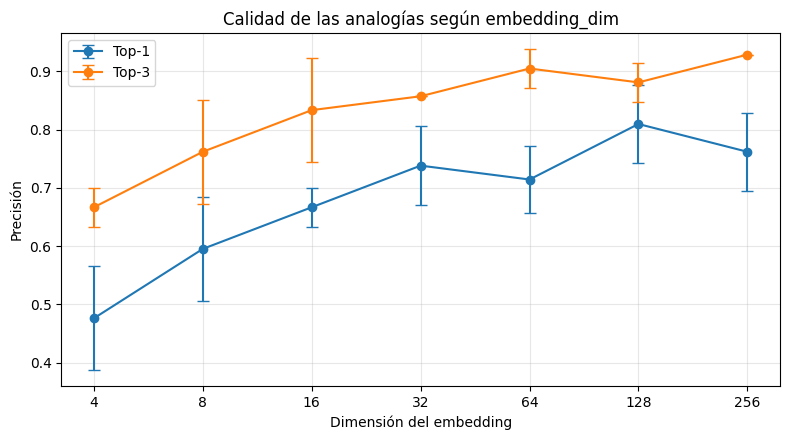

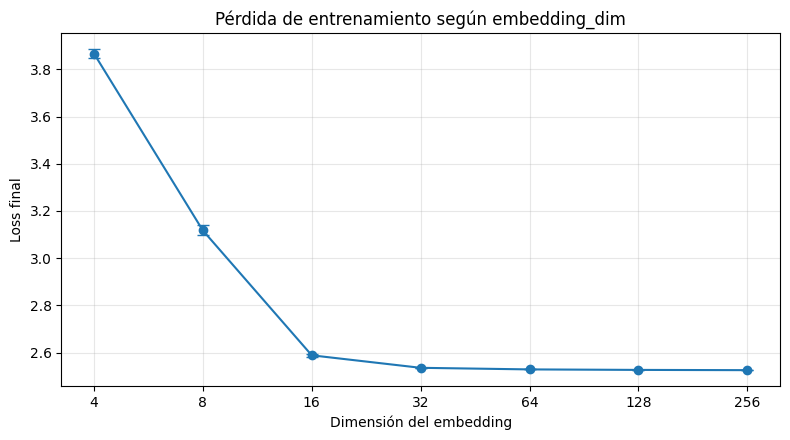

Dimensión con mayor Top-1 medio en la batería utilizada: D = 128


In [15]:
plt.figure(figsize=(8, 4.5))

plt.errorbar(
    resultados_dim["embedding_dim"],
    resultados_dim["top1_mean"],
    yerr=resultados_dim["top1_std"],
    marker="o",
    capsize=4,
    label="Top-1"
)

plt.errorbar(
    resultados_dim["embedding_dim"],
    resultados_dim["top3_mean"],
    yerr=resultados_dim["top3_std"],
    marker="o",
    capsize=4,
    label="Top-3"
)

plt.xscale("log", base=2)

plt.xticks(
    DIMENSIONES,
    DIMENSIONES
)

plt.xlabel("Dimensión del embedding")
plt.ylabel("Precisión")
plt.title("Calidad de las analogías según embedding_dim")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Loss
plt.figure(figsize=(8, 4.5))

plt.errorbar(
    resultados_dim["embedding_dim"],
    resultados_dim["loss_mean"],
    yerr=resultados_dim["loss_std"],
    marker="o",
    capsize=4
)

plt.xscale("log", base=2)

plt.xticks(
    DIMENSIONES,
    DIMENSIONES
)

plt.xlabel("Dimensión del embedding")
plt.ylabel("Loss final")
plt.title("Pérdida de entrenamiento según embedding_dim")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Selección según Top-1 medio
ranking_dim = resultados_dim.sort_values(
    by=[
        "top1_mean",
        "top3_mean",
        "embedding_dim"
    ],
    ascending=[
        False,
        False,
        True
    ]
)

best_dim = int(
    ranking_dim.iloc[0]["embedding_dim"]
)

print(
    "Dimensión con mayor Top-1 medio "
    f"en la batería utilizada: D = {best_dim}"
)

### Análisis de los resultados

El efecto de la dimensionalidad es especialmente visible en las representaciones más pequeñas.

El Top-1 aumenta de **47,6 % con D = 4** a **59,5 % con D = 8**, **66,7 % con D = 16** y **73,8 % con D = 32**. Esta progresión indica que las dimensiones iniciales limitan la capacidad del espacio para representar las relaciones evaluadas.

A partir de 32 dimensiones el comportamiento deja de ser monotónico. `D = 64` obtiene un Top-1 ligeramente inferior, del **71,4 %**, mientras que `D = 128` alcanza el mejor resultado Top-1, con **81,0 % ± 6,7 %**. Al aumentar hasta `D = 256`, el Top-1 vuelve a descender hasta **76,2 %**, aunque esta configuración consigue el mejor Top-3, con **92,9 %**.

La evolución de la pérdida es diferente. Esta disminuye continuamente al aumentar la dimensionalidad, desde 3,868 con D = 4 hasta 2,525 con D = 256. Sin embargo, a partir de aproximadamente 32 dimensiones la reducción es mínima: pasa de 2,535 con D = 32 a 2,525 con D = 256.

Durante ese mismo intervalo, el número de parámetros aumenta de **22.784 a 182.272**, es decir, se multiplica por ocho.

Por tanto, los resultados muestran que una mayor capacidad del modelo puede reducir ligeramente la pérdida de entrenamiento sin producir una mejora equivalente y monotónica en la calidad de las analogías.

Según el criterio Top-1 utilizado para seleccionar el modelo, la mejor configuración entre las evaluadas es **D = 128**.

### 12.1 Evolución cualitativa de los vecinos según la dimensión

Las métricas anteriores resumen el comportamiento de las analogías, pero resulta útil comprobar qué ocurre realmente con el espacio semántico.

Se observarán los vecinos de las mismas palabras utilizando modelos con diferentes dimensiones.

Esto permite visualizar el significado práctico de aumentar `embedding_dim`.

Con muy pocas dimensiones, distintas relaciones deben comprimirse en un espacio muy reducido y es posible que palabras no relacionadas terminen próximas entre sí.

Al aumentar la dimensión, el modelo dispone de más grados de libertad para organizar el vocabulario.

Sin embargo, si llega un momento en el que los vecinos dejan de mejorar de manera clara, seguir añadiendo dimensiones puede estar aumentando principalmente la capacidad del modelo y no la calidad de la representación.

In [16]:
palabras_comparacion = [
    "perro",
    "gata",
    "parís",
    "francia",
    "coche"
]

filas = []

for dim in DIMENSIONES:

    modelo = modelos_dim[dim]

    E = (
        modelo
        .embedding
        .weight
        .detach()
        .clone()
    )

    fila = {
        "embedding_dim": dim
    }

    for palabra in palabras_comparacion:

        vecinos_dim = vecinos(
            palabra,
            E,
            k=5
        )

        fila[palabra] = ", ".join(
            vecino
            for vecino, _ in vecinos_dim
        )

    filas.append(fila)


comparacion_vecinos = pd.DataFrame(filas)

display(comparacion_vecinos)

,embedding_dim,perro,gata,parís,francia,coche
0,4,"juega, gato, suelo, sofá, sal","perra, la, mochila, costa, montaña","madrid, roma, gris, marrón, viento","españa, italia, parís, madrid, grande","profesora, ingeniero, pintor, ingeniera, lee"
1,8,"gato, alumno, té, parque, camarero","perra, leche, con, costa, hermana","madrid, roma, frío, rey, españa","italia, españa, palacio, país, vive","verano, libro, rey, vaso, niño"
2,16,"gato, verano, pequeño, ladra, grande","perra, gato, viento, duerme, primavera","roma, madrid, españa, francia, italia","italia, españa, palacio, madrid, país","conductor, alumno, invierno, rojo, verano"
3,32,"gato, cuaderno, sofá, campo, suelo","perra, mochila, costa, entro, montaña","roma, madrid, francia, españa, italia","italia, españa, palacio, país, madrid","cuadro, profesor, país, conductor, avión"
4,64,"gato, perra, suelo, ratón, niño","perra, entro, gato, mochila, puerta","madrid, roma, españa, francia, italia","españa, italia, roma, palacio, madrid","cuadro, conductor, verano, país, invierno"
5,128,"gato, patio, cuaderno, suelo, sofá","perra, fuente, entro, montaña, costa","roma, madrid, francia, españa, italia","italia, españa, roma, madrid, parís","conductor, invierno, país, cuadro, profesor"
6,256,"gato, cuaderno, sofá, patio, campo","perra, fuente, mochila, costa, cuerda","roma, madrid, italia, españa, francia","italia, españa, roma, madrid, parís","invierno, verano, conductor, profesor, cuadro"


### Interpretación conjunta de la dimensión

Esta tabla debe analizarse conjuntamente con las métricas anteriores.

El objetivo no es que todas las palabras produzcan vecinos intuitivamente perfectos, ya que el corpus es extremadamente reducido. Lo importante es estudiar si existe una tendencia general:

- las dimensiones muy pequeñas pierden relaciones útiles;
- aumentar la dimensión mejora inicialmente la organización del espacio;
- a partir de cierto punto las mejoras pueden reducirse, estabilizarse o variar entre semillas.

También debe prestarse atención a las diferencias entre `loss` y calidad semántica.

Si una dimensión mayor consigue una pérdida inferior pero no mejora de forma consistente Top-1, Top-3 o los vecinos, ese resultado indica que **mayor capacidad de ajuste no equivale necesariamente a mejores embeddings**.

Esta distinción es uno de los principales resultados del experimento.

### 13. Influencia de otros hiperparámetros

Además de la dimensión del embedding, se evaluará brevemente la influencia de:

- tamaño de la ventana;
- número de épocas;
- learning rate.

Para estas comparaciones se utilizará como dimensión fija `D = 128`, seleccionada anteriormente por presentar el mayor Top-1 medio.

Cada configuración se entrenará nuevamente utilizando tres semillas para reducir el efecto de la inicialización aleatoria.

In [17]:
def experimento_parametro(
    parametro,
    valores,
    configuracion_base,
    semillas=(0, 1, 2)
):
    """
    Evalúa diferentes valores de un hiperparámetro manteniendo
    constantes los demás elementos de la configuración.
    """

    filas = []

    for valor in valores:

        resultados = []

        for seed in semillas:

            config = configuracion_base.copy()
            config[parametro] = valor

            modelo, historial = entrenar_skipgram(
                corpus=corpus,
                palabra2id=palabra2id,
                vocab_size=V,
                embedding_dim=config["embedding_dim"],
                window=config["window"],
                epochs=config["epochs"],
                lr=config["lr"],
                seed=seed,
                verbose=False
            )

            E = (
                modelo
                .embedding
                .weight
                .detach()
                .clone()
            )

            top1, top3, _ = evaluar_analogias(E)

            resultados.append([
                historial[-1],
                top1,
                top3
            ])

        resultados = np.asarray(
            resultados,
            dtype=float
        )

        filas.append({
            parametro: valor,

            "loss_mean": resultados[:, 0].mean(),
            "loss_std": resultados[:, 0].std(),

            "top1_mean": resultados[:, 1].mean(),
            "top1_std": resultados[:, 1].std(),

            "top3_mean": resultados[:, 2].mean(),
            "top3_std": resultados[:, 2].std(),
        })

    return pd.DataFrame(filas)


def formatear_resultados(df, parametro):
    """
    Genera una tabla legible con media ± desviación típica.
    """

    tabla = df[[parametro]].copy()

    tabla["Loss"] = df.apply(
        lambda fila:
        f"{fila['loss_mean']:.3f} ± {fila['loss_std']:.3f}",
        axis=1
    )

    tabla["Top-1"] = df.apply(
        lambda fila:
        f"{fila['top1_mean']:.1%} ± {fila['top1_std']:.1%}",
        axis=1
    )

    tabla["Top-3"] = df.apply(
        lambda fila:
        f"{fila['top3_mean']:.1%} ± {fila['top3_std']:.1%}",
        axis=1
    )

    return tabla


CONFIG_BASE = {
    "embedding_dim": best_dim,
    "window": 2,
    "epochs": 200,
    "lr": 0.01,
}


# Tamaño de ventana
resultados_window = experimento_parametro(
    parametro="window",
    valores=[1, 2, 3],
    configuracion_base=CONFIG_BASE,
    semillas=SEMILLAS_EXPERIMENTO
)


# Número de épocas
resultados_epochs = experimento_parametro(
    parametro="epochs",
    valores=[50, 100, 200],
    configuracion_base=CONFIG_BASE,
    semillas=SEMILLAS_EXPERIMENTO
)


# Learning rate
resultados_lr = experimento_parametro(
    parametro="lr",
    valores=[0.001, 0.01, 0.05],
    configuracion_base=CONFIG_BASE,
    semillas=SEMILLAS_EXPERIMENTO
)


print("Tamaño de ventana")
display(
    formatear_resultados(
        resultados_window,
        "window"
    )
)

print("\nNúmero de épocas")
display(
    formatear_resultados(
        resultados_epochs,
        "epochs"
    )
)

print("\nLearning rate")
display(
    formatear_resultados(
        resultados_lr,
        "lr"
    )
)

Tamaño de ventana


,window,Loss,Top-1,Top-3
0,1,2.032 ± 0.000,78.6% ± 5.8%,88.1% ± 3.4%
1,2,2.526 ± 0.000,81.0% ± 6.7%,88.1% ± 3.4%
2,3,2.744 ± 0.000,66.7% ± 8.9%,92.9% ± 0.0%



Número de épocas


,epochs,Loss,Top-1,Top-3
0,50,2.567 ± 0.001,81.0% ± 6.7%,88.1% ± 3.4%
1,100,2.530 ± 0.000,81.0% ± 6.7%,88.1% ± 3.4%
2,200,2.526 ± 0.000,81.0% ± 6.7%,88.1% ± 3.4%



Learning rate


,lr,Loss,Top-1,Top-3
0,0.001,3.083 ± 0.007,61.9% ± 8.9%,81.0% ± 6.7%
1,0.010,2.526 ± 0.000,81.0% ± 6.7%,88.1% ± 3.4%
2,0.050,2.527 ± 0.002,83.3% ± 3.4%,92.9% ± 0.0%


### Interpretación de los hiperparámetros

El tamaño de la ventana modifica de forma apreciable los resultados. `window = 2` obtiene el mejor Top-1 de las configuraciones comparadas, con aproximadamente **81,0 %**, frente al **78,6 %** de `window = 1` y el **66,7 %** de `window = 3`.

Sin embargo, `window = 3` presenta el mayor Top-3, con aproximadamente **92,9 %**. Esto indica que una ventana más amplia puede situar con frecuencia la respuesta correcta entre las primeras candidatas, aunque reduce su capacidad para colocarla específicamente en primera posición. En un corpus formado por frases tan cortas, una ventana excesivamente amplia puede hacer que gran parte de la oración pase a considerarse contexto.

El número de épocas muestra un comportamiento diferente. Entre **50, 100 y 200 épocas**, tanto Top-1 como Top-3 permanecen prácticamente constantes, mientras que la pérdida continúa descendiendo de aproximadamente **2,567 a 2,526**. Esto constituye otra evidencia de que reducir la pérdida de entrenamiento no implica necesariamente mejorar la estructura semántica de los embeddings.

Respecto al learning rate, `lr = 0.001` produce resultados claramente inferiores, con aproximadamente **61,9 % Top-1**. `lr = 0.01` mejora hasta **81,0 %**, mientras que `lr = 0.05` alcanza el mejor resultado entre los valores probados, con aproximadamente **83,3 % Top-1 y 92,9 % Top-3**.

Por tanto, dentro del rango analizado no se observa inestabilidad con `lr = 0.05`; al contrario, proporciona una convergencia adecuada y el mejor comportamiento en las analogías.

### 14. Visualización bidimensional de los embeddings

Los embeddings aprendidos poseen tantas dimensiones como indique `embedding_dim`, por lo que no pueden representarse directamente en una gráfica convencional cuando D > 2.

Como complemento visual se utilizará **PCA (Principal Component Analysis)** para proyectar un pequeño conjunto de palabras sobre dos dimensiones.

Esta representación debe interpretarse únicamente como una visualización.

PCA descarta parte de la información existente en el espacio original, por lo que las distancias observadas en dos dimensiones no deben utilizarse como métrica principal para decidir qué modelo es mejor.

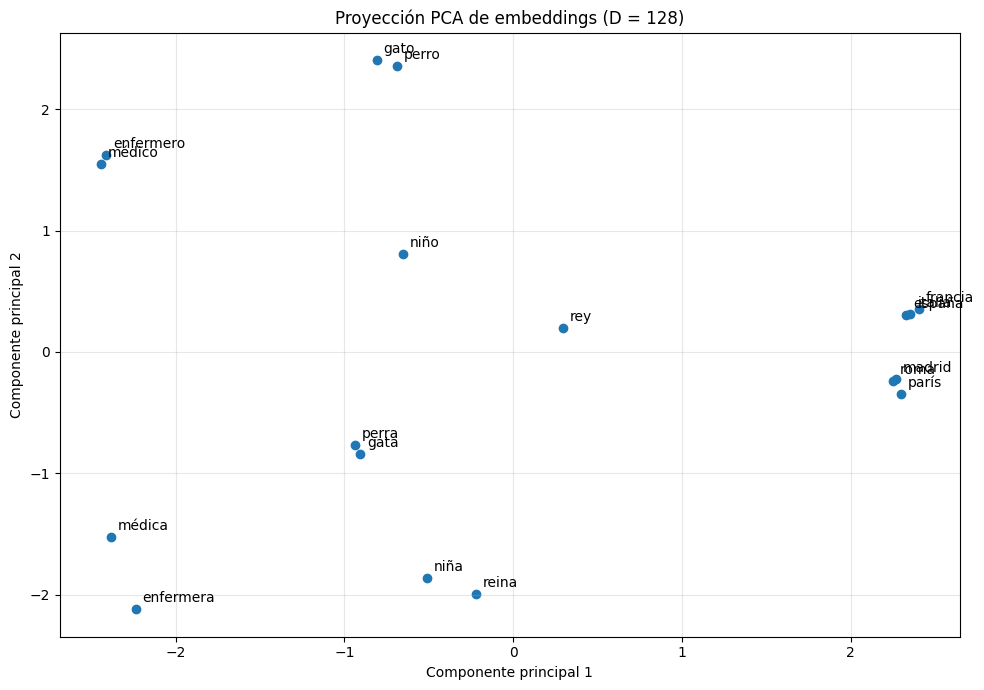

Varianza explicada por las dos componentes: 41.5%


In [18]:
# Modelo representativo de la dimensión seleccionada
modelo_visual = modelos_dim[best_dim]

E_visual = (
    modelo_visual
    .embedding
    .weight
    .detach()
    .numpy()
)


palabras_pca = [
    "perro", "perra",
    "gato", "gata",
    
    "parís", "madrid", "roma",
    "francia", "españa", "italia",
    
    "médico", "médica",
    "enfermero", "enfermera",
    
    "rey", "reina",
    "niño", "niña"
]


indices_pca = [
    palabra2id[palabra]
    for palabra in palabras_pca
]


vectores_pca = E_visual[indices_pca]


pca = PCA(
    n_components=2,
    random_state=SEED
)

coordenadas = pca.fit_transform(
    vectores_pca
)


plt.figure(figsize=(10, 7))
plt.scatter(
    coordenadas[:, 0],
    coordenadas[:, 1]
)

for i, palabra in enumerate(palabras_pca):
    plt.annotate(
        palabra,
        (
            coordenadas[i, 0],
            coordenadas[i, 1]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(
    f"Proyección PCA de embeddings "
    f"(D = {best_dim})"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Varianza explicada por las dos componentes:",
    f"{pca.explained_variance_ratio_.sum():.1%}"
)

Las dos primeras componentes principales explican aproximadamente el **41,5 % de la varianza** del subconjunto representado.

Por tanto, la proyección conserva una parte relevante de la estructura, pero también descarta más de la mitad de la variabilidad original. Las proximidades observadas en el plano deben interpretarse teniendo en cuenta esta pérdida de información.

### 15. Conclusiones

La implementación de Skip-gram mediante PyTorch ha permitido obtener representaciones vectoriales capaces de capturar varias de las relaciones distribucionales presentes en el corpus.

El análisis de vecinos muestra resultados especialmente claros en determinados grupos. `perro` y `gato`, `gata` y `perra`, las ciudades `parís`, `madrid` y `roma`, y los países `francia`, `españa` e `italia` aparecen próximos en el espacio aprendido. Esto confirma que Word2Vec aproxima palabras que aparecen en contextos semejantes, aunque no sean necesariamente sinónimos.

Las analogías proporcionan una evaluación más exigente. El modelo de referencia con 32 dimensiones obtiene un **71,4 % Top-1 y un 85,7 % Top-3**, resolviendo correctamente numerosas relaciones geográficas y de género.

### Influencia de la dimensión del embedding

La dimensionalidad presenta un efecto claro cuando el espacio vectorial es muy reducido. El Top-1 aumenta progresivamente desde **47,6 % con 4 dimensiones** hasta **73,8 % con 32 dimensiones**.

A partir de ese punto la mejora deja de ser monotónica. La configuración con **128 dimensiones obtiene el mejor Top-1, con 81,0 % ± 6,7 %**, mientras que 256 dimensiones reduce el Top-1 hasta **76,2 %**, aunque consigue el mejor Top-3 con **92,9 %**.

La pérdida de entrenamiento, en cambio, disminuye prácticamente de forma continua al aumentar la dimensionalidad. Entre 32 y 256 dimensiones pasa únicamente de **2,535 a 2,525**, mientras que el número de parámetros aumenta de **22.784 a 182.272**.

Este resultado muestra que incrementar la capacidad del modelo puede mejorar ligeramente el ajuste a los datos sin producir necesariamente una mejora equivalente en la estructura semántica de los embeddings.

Entre las configuraciones evaluadas, **D = 128 ofrece el mejor resultado según Top-1**. No obstante, 32 dimensiones ya proporcionan un rendimiento elevado con una cuarta parte de los parámetros, por lo que constituyen una alternativa considerablemente más compacta.

### Influencia del resto de hiperparámetros

Una ventana de tamaño 2 ofrece el mejor Top-1 entre las configuraciones analizadas. Aumentarla hasta 3 reduce este resultado, probablemente porque las frases son suficientemente cortas como para que una ventana amplia incorpore relaciones contextuales menos específicas.

El número de épocas presenta rendimientos decrecientes: entre 50 y 200 épocas la pérdida continúa reduciéndose, pero Top-1 y Top-3 permanecen prácticamente constantes.

El learning rate también presenta un efecto apreciable. Entre los valores probados, `lr = 0.05` obtiene los mejores resultados, mientras que `lr = 0.001` produce un aprendizaje claramente más limitado.

### Limitaciones

La principal limitación del experimento es el tamaño del corpus. Contiene únicamente 1.148 tokens y aproximadamente el 48 % de las palabras diferentes aparecen una sola vez. Como consecuencia, muchos embeddings deben estimarse utilizando muy poca evidencia contextual.

Además, los hiperparámetros se han estudiado principalmente de forma independiente. No se ha realizado una búsqueda exhaustiva de todas sus posibles combinaciones, por lo que pueden existir interacciones entre dimensión, ventana, learning rate y número de épocas.

Los resultados deben interpretarse, por tanto, como una demostración controlada del funcionamiento de Skip-gram y de la influencia de sus hiperparámetros sobre un corpus reducido, y no como representaciones generales del idioma español.